Valores ausentes por coluna:
Unnamed: 0        0
id                0
age               0
male              0
weight            0
height            0
bmi               0
case.id           0
futime            0
status            0
days          17549
test          17549
value         17549
dtype: int64


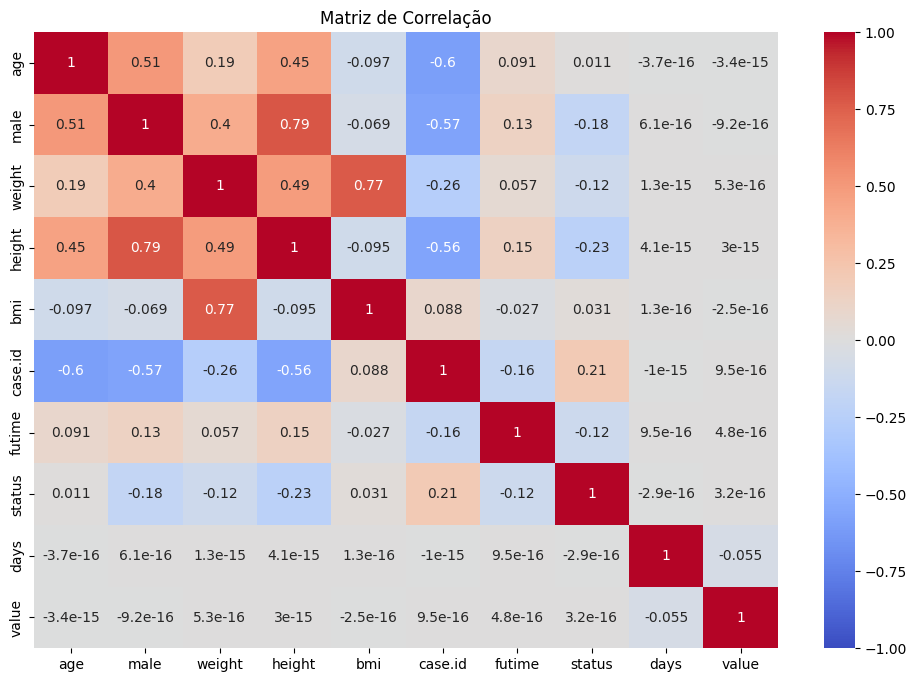

Correlação com a variável target (status):
status     1.000000e+00
case.id    2.077590e-01
bmi        3.105949e-02
age        1.120252e-02
value      3.168648e-16
days      -2.939625e-16
weight    -1.154323e-01
futime    -1.210579e-01
male      -1.825529e-01
height    -2.341956e-01
Name: status, dtype: float64


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Caminho para os dados Silver
silver_path = '../data/silver/nafld_merged.parquet'

# Leitura do arquivo Parquet
df = pd.read_parquet(silver_path, engine='pyarrow')

# Verificar valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())

# Remover colunas não numéricas
df = df.drop(columns=['Unnamed: 0', 'id', 'test'])

# Preencher valores ausentes com a média das colunas numéricas
df.fillna(df.mean(), inplace=True)

# Calcular a correlação
correlation = df.corr()

# Plotar a matriz de correlação
plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação')
plt.show()

# Correlação com a variável target
print("Correlação com a variável target (status):")
print(correlation['status'].sort_values(ascending=False))